Import libraries


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay


Load dataset

In [18]:
df = pd.read_csv("hairstyle_prediction_dataset_1000.csv")


Feature engineering

Train-test split

In [19]:
X = df[['face_width','jaw_width', 'forehead_width', 'chin_length']]
y = df['face_shape']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Feature scaling

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Model training with hyper parameter tuning

In [21]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

#Split training data into 5 folds. For each parameter combo, it trains on 4 folds and validates on 1

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

best_knn = grid_search.best_estimator_
print("Best Params:", grid_search.best_params_)

Best Params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}


Model evaluation

In [22]:
y_pred = best_knn.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.925
              precision    recall  f1-score   support

       heart       0.96      0.75      0.84        32
      oblong       0.93      0.93      0.93        43
        oval       0.94      0.92      0.93        37
       round       0.84      0.98      0.90        43
      square       0.98      1.00      0.99        45

    accuracy                           0.93       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.93      0.92       200



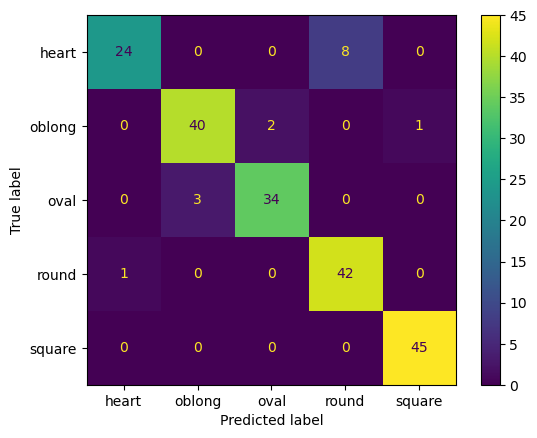

In [23]:
#compares the actual labels (true values) with the predicted labels 

ConfusionMatrixDisplay.from_estimator(best_knn, X_test_scaled, y_test)


Predict New Inputs + Rule-Based Mapping

In [24]:
# Build dictionary
face_to_hairstyle = df.drop_duplicates(subset=['face_shape'])[['face_shape','best_hairstyle']].set_index('face_shape')['best_hairstyle'].to_dict()

def predict_face_and_hairstyle(input_features):
    input_df = pd.DataFrame([input_features], columns=['face_width','jaw_width', 'forehead_width', 'chin_length'])
    scaled_input = scaler.transform(input_df)
    predicted_shape = best_knn.predict(scaled_input)[0]
    recommended = face_to_hairstyle.get(predicted_shape, "No suggestion")
    return predicted_shape, recommended

# Example
shape, style = predict_face_and_hairstyle([150, 130, 153, 50])
print("Predicted Shape:", shape)
print("Recommended Hairstyle:", style)


Predicted Shape: oblong
Recommended Hairstyle: fringe_bangs
